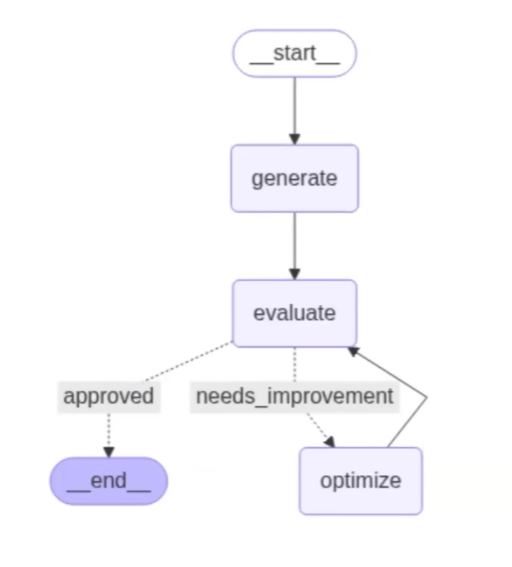

In [1]:
from langgraph.graph import StateGraph,START, END
from typing import TypedDict, Literal, Annotated
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
import operator
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
#Normally all these LLMs should be different
generator_llm = ChatOpenAI(model='gpt-4o-mini')
evaluator_llm = ChatOpenAI(model='gpt-4o-mini')
optimizer_llm = ChatOpenAI(model='gpt-4o-mini')

In [5]:
from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [6]:
from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [7]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [8]:
# state
class TweetState(TypedDict):

    topic: str
    tweet: str
    evaluation: Literal["approved", "needs_improvement"]
    feedback: str
    iteration: int
    max_iteration: int

    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [9]:
def generate_tweet(state: TweetState):

    # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
        Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

        Rules:
        - Do NOT use question-answer format.
        - Max 280 characters.
        - Use observational humor, irony, sarcasm, or cultural references.
        - Think in meme logic, punchlines, or relatable takes.
        - Use simple, day to day english
        """)
    ]

    # send generator_llm
    response = generator_llm.invoke(messages).content

    # return response
    return {'tweet': response, 'tweet_history': [response]}

In [10]:
def evaluate_tweet(state: TweetState):

    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

In [11]:
def optimize_tweet(state: TweetState):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [12]:
def route_evaluation(state: TweetState):

    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

In [19]:
"""
SYNTAX for graph.add_conditional_edge:

# Syntax
builder.add_conditional_edges(
    "start_node",          # Source node
    routing_function,      # Returns next node name
    { "path_a": "node_a", "path_b": "node_b", "end": END } # Optional mapping
)


"""

'\nSYNTAX for graph.add_conditional_edge:\n\n# Syntax\nbuilder.add_conditional_edges(\n    "start_node",          # Source node\n    routing_function,      # Returns next node name\n    { "path_a": "node_a", "path_b": "node_b", "end": END } # Optional mapping\n)\n\n\n'

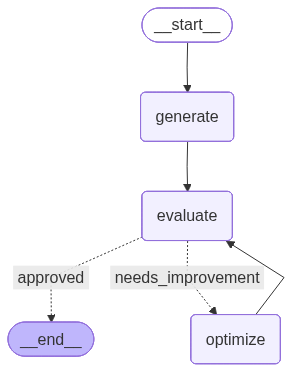

In [13]:
graph = StateGraph(TweetState)

graph.add_node('generate', generate_tweet)
graph.add_node('evaluate', evaluate_tweet)
graph.add_node('optimize', optimize_tweet)

graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')

graph.add_conditional_edges('evaluate', route_evaluation, {'approved': END, 'needs_improvement': 'optimize'})
graph.add_edge('optimize', 'evaluate')

workflow = graph.compile()

workflow

In [20]:
initial_state = {
    "topic": "srhberhb",
    "iteration": 1,
    "max_iteration": 5
}
result = workflow.invoke(initial_state)

In [21]:
result

{'topic': 'srhberhb',
 'tweet': 'Just saw "srhberhb" in a text. If that’s a new motivational mantra, I’m here for it: "Confused yet thriving!" 😂💥 Who knew chaos could sound like a typo! #InspiredByNonsense #LivingMyBestMistake',
 'evaluation': 'approved',
 'feedback': "This tweet showcases originality with a unique take on a seemingly random text, blending chaos and motivation in an amusingly absurd way. The humor is light and engaging, eliciting a smile with its relatable concept of finding meaning in confusion. It's punchy enough to grab attention due to its unexpected twist and the amusing phrase 'Confused yet thriving!' The incorporation of hashtags enhances its potential virality, encouraging others to share their own experiences with nonsense. Overall, it's a well-structured tweet that fits within the character limit and avoids cliches.",
 'iteration': 3,
 'max_iteration': 5,
 'tweet_history': ['Just saw someone type "srhberhb" instead of a real word. At this point, I’m convinced

In [16]:
for tweet in result['tweet_history']:
    print(tweet)

Just spent an hour trying to decode "srhberhb." Turns out it’s just how I type when I’m trying to look busy at work. If you need me, I’ll be here deploying my new strategy: finger gymnastics while staring blankly into space. 🖥️💼 #ProductivityExpert #NailedIt


In [22]:
initial_state = {
    "topic": "moonlighting",
    "iteration": 1,
    "max_iteration": 5
}
result = workflow.invoke(initial_state)

In [23]:
result

{'topic': 'moonlighting',
 'tweet': 'Moonlighting: the art of pretending your side hustle is "just a hobby" while your real job is silently judging you for wearing sweatpants and calling it "business casual." If only spreadsheets could appreciate my TikTok choreography! 🕺🌙 #SideHustleStruggles #MoonlightMagic',
 'evaluation': 'approved',
 'feedback': 'This tweet stands out with its originality by cleverly blending the themes of side hustles and the mundanity of office culture. The humor is palpable, as it encapsulates a relatable experience while also delivering a whimsical take on the dichotomy between professional life and personal passions. The punchiness is commendable, with a format that captures attention, and the playful language keeps it engaging without feeling like a long-winded explanation. Additionally, the use of relevant hashtags boosts its virality potential, making it more shareable.',
 'iteration': 1,
 'max_iteration': 5,
 'tweet_history': ['Moonlighting: the art of pr